# `balanced_mm` — OPM / OGM-GE walkthrough (Text + Image)

Is notebook me (sab kuch **CPU** pe, chhote settings):

1. synthetic Text + Image data pe **bina modulation** training (`none`)
2. wahi **OGM-GE** ke saath — discrepancy ratio `ρ` 1 ki taraf kaise aata hai
3. accuracy + ρ curves ka comparison plot
4. **XAI modality attribution** (Integrated Gradients + gradient×input) —
   training ke baad kaunsi modality kaam kar rahi hai

> GitHub pe isi page ka **Preview** tab me code + output dono dikhte hain.
> Khud chalane ke liye: `balanced_mm/` me `pip install -r requirements.txt`,
> phir `python scripts/build_walkthrough_notebook.py` (ya Jupyter me khol kar Run).
> Pura benchmark: `bash scripts/run_synthetic_compare.sh` + `bash scripts/run_seed_sweep.sh`,
> report: `python scripts/make_report.py` → `results/RESULTS.md`.

In [1]:
%matplotlib inline
import json, os, sys
import matplotlib.pyplot as plt
import torch

# project root chaho (repo ke balanced_mm/ se chalao, ya notebooks/ se bhi chalega)
ROOT = os.path.abspath(os.getcwd())
if os.path.basename(ROOT) == "notebooks":
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
TMP = os.path.join(ROOT, "notebooks", "_walkthrough_tmp")
os.makedirs(TMP, exist_ok=True)

from train import main as train_main
print("root:", ROOT)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

root: /home/user/DL_project/balanced_mm
torch: 2.14.0+cpu | cuda: False


## 1–2. Train: `none` vs `ogm`

Chhota setup: 800 train / 300 val, 4 epochs, SmallCNN (64×64) + 2-layer Transformer text encoder,
SGD lr 0.01 — dono runs **ek hi seed** (0) se, taaki sirf modulation ka farq dikhe.

In [2]:
def run(modulation, out_name):
    out_dir = os.path.join(TMP, out_name)
    summary = train_main([
        "--data", "synthetic", "--image_encoder", "smallcnn", "--img_size", "64",
        "--epochs", "4", "--batch_size", "32",
        "--syn_train_n", "800", "--syn_val_n", "300",
        "--lr", "0.01", "--num_workers", "0", "--log_interval", "0", "--seed", "0",
        "--modulation", modulation, "--out_dir", out_dir,
    ])
    return out_dir, summary

dir_none, sum_none = run("none", "none")
dir_ogm, sum_ogm = run("ogm", "ogm")
print()
print(f"best val acc | none: {sum_none['best_val_acc']:.3f}   ogm: {sum_ogm['best_val_acc']:.3f}")

device=cpu  args={'data': 'synthetic', 'train_csv': None, 'val_csv': None, 'test_csv': None, 'img_root': '', 'col_image': 'image', 'col_text': 'text', 'col_label': 'label', 'img_size': 64, 'max_len': 64, 'min_freq': 2, 'max_vocab': 30000, 'num_classes': 6, 'syn_train_n': 800, 'syn_val_n': 300, 'syn_text_p': 0.7, 'syn_img_p': 0.7, 'syn_img_noise': 1.0, 'syn_synonyms': 1, 'image_encoder': 'smallcnn', 'pretrained_image': False, 'text_encoder': 'transformer', 'hf_model': 'distilbert-base-uncased', 'freeze_hf': False, 'text_dim': 256, 'text_layers': 2, 'head': 'linear', 'only': 'none', 'modulation': 'none', 'q_base': 0.5, 'lam': 0.5, 'alpha': 0.5, 'no_ge': False, 'ge_scope': 'all', 'z': 'tanh', 'score_mode': 'auto', 'mod_start': 0, 'mod_end': 1000000000, 'epochs': 4, 'batch_size': 32, 'optimizer': 'sgd', 'lr': 0.01, 'lr_text': None, 'momentum': 0.9, 'weight_decay': 0.0001, 'sched': 'cos', 'lr_step': 30, 'lr_gamma': 0.1, 'grad_clip': None, 'amp': False, 'num_workers': 0, 'seed': 0, 'device':

classes=6 vocab=400 train_batches=25 val_batches=10


model params: image=241,184 text=1,288,192 head=2,310


/home/user/DL_project/balanced_mm/bml/models.py:74: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(layer, num_layers)


[ep 000] train loss=1.8351 acc=0.1913 | rho_image=0.98 rho_text=1.02 | k_image=1.00 q_image=0.00 k_text=1.00 q_text=0.00 || val acc=0.3333 uni_image=0.1767 uni_text=0.3433 | 13s


...

[ep 001] train loss=1.6165 acc=0.3725 | rho_image=1.03 rho_text=0.97 | k_image=0.98 q_image=0.00 k_text=0.99 q_text=0.00 || val acc=0.3533 uni_image=0.2067 uni_text=0.5000 | 14s


[ep 002] train loss=1.2972 acc=0.7113 | rho_image=1.22 rho_text=0.83 | k_image=0.89 q_image=0.00 k_text=1.00 q_text=0.00 || val acc=0.4967 uni_image=0.3867 uni_text=0.4933 | 14s


[ep 003] train loss=1.0742 acc=0.8500 | rho_image=1.45 rho_text=0.70 | k_image=0.79 q_image=0.00 k_text=1.00 q_text=0.00 || val acc=0.6533 uni_image=0.4767 uni_text=0.5567 | 15s


best val acc=0.6533 @ epoch 3



best val acc | none: 0.663   ogm: 0.653


## 3. Curves: accuracy upar, ρ (bias) neeche

`ρ_image` = discrepancy ratio (Eq 7). **1 = balanced**, >1 = image dominant.

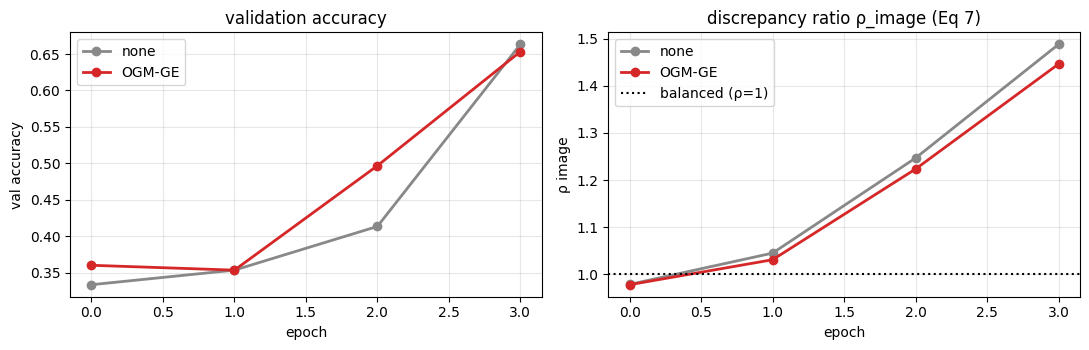

In [3]:
def hist(d):
    return json.load(open(os.path.join(d, "history.json")))

h0, h1 = hist(dir_none), hist(dir_ogm)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for name, h, c in [("none", h0, "#888888"), ("OGM-GE", h1, "#d62728")]:
    xs = [r["epoch"] for r in h if "val_acc" in r]
    ys = [r["val_acc"] for r in h if "val_acc" in r]
    ax[0].plot(xs, ys, marker="o", label=name, color=c, lw=2)
    ax[1].plot([r["epoch"] for r in h], [r["train_rho_image"] for r in h],
               marker="o", label=name, color=c, lw=2)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("val accuracy")
ax[0].set_title("validation accuracy"); ax[0].grid(alpha=0.3); ax[0].legend()
ax[1].axhline(1.0, ls=":", c="k", label="balanced (ρ=1)")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("ρ image")
ax[1].set_title("discrepancy ratio ρ_image (Eq 7)"); ax[1].grid(alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. XAI side — modality attribution (`bml/xai.py`)

Trained checkpoint le kar val batch par:

- **image** → Integrated Gradients (pixels par, completeness property ke saath)
- **text** → gradient × embedding (tokens ke liye standard relevance score)

Dono ko `share` me normalise karo → "kaunsi modality ne kitna contribute kiya".

prediction vs truth : [1, 1, 2, 0, 5, 5, 0, 1] [0, 1, 2, 3, 4, 5, 0, 1]
attribution shares   : {'image': 0.971, 'text': 0.029}


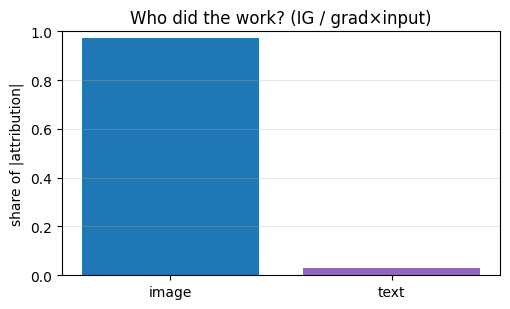

In [4]:
from argparse import Namespace
from bml.data import build_dataloaders
from bml.xai import modality_attribution
from train import build_model

cfg = Namespace(**json.load(open(os.path.join(dir_none, "config.json"))))
data = build_dataloaders(cfg, out_dir=dir_none)
model = build_model(cfg, data["num_classes"], data["vocab_size"])
ck = torch.load(os.path.join(dir_none, "best.pt"), map_location="cpu", weights_only=False)
model.load_state_dict(ck["model"])
model.eval()

inputs, y = next(iter(data["loaders"]["val"]))
att = modality_attribution(model, inputs, steps=16)
print("prediction vs truth :", att["predicted"][:8], y[:8].tolist())
print("attribution shares   :", {k: round(v, 3) for k, v in att["share"].items()})

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ks = list(att["share"])
ax.bar(ks, [att["share"][k] for k in ks], color=["#1f77b4", "#9467bd"])
ax.set_ylim(0, 1); ax.set_ylabel("share of |attribution|")
ax.set_title("Who did the work? (IG / grad×input)")
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## Aage kya dekhna hai

- **Pura benchmark + mean±std (3 seeds):** `results/RESULTS.md` (plots `results/*.png`)
- **Compare table CLI:** `python compare.py runs/syn_none runs/syn_opm runs/syn_ogm runs/syn_both`
- **Apne CSV data pe:** `python train.py --data csv --train_csv ... --modulation both` (`plug_in_example.py` dekho)
- **Modulation ke 7 unit tests + pipeline tests:** `python -m pytest tests/` (27 tests)
- **Review prep (likely Q&A):** [`docs/REVIEW_QA.md`](../docs/REVIEW_QA.md)

`--modulation {none|opm|ogm|both}` — bas yahi flag lagta hai; module `bml/modulation.py`
standalone hai (paper: Wei et al., TPAMI 2024).